# Tuning FLORIS using ModelFit

Demonstrate tuning of FLORIS to the SCADA data using the ModelFit object

In [41]:
from pathlib import Path

import numpy as np
import pandas as pd
from floris import UncertainFlorisModel
from optuna.visualization.matplotlib import (
    plot_slice,
)

from flasc.data_processing.dataframe_manipulations import (
    is_day_or_night,
)
from flasc.model_fit.cost_library import turbine_power_error_abs
from flasc.model_fit.model_fit import ModelFit
from flasc.model_fit.opt_library import atomic_opt_optuna
from flasc.utilities.utilities_examples import load_floris_smarteole

from flasc.utilities.floris_tools import (
    estimate_ws_with_floris,
)

## Read data and prepare data

Use previously definied 60s data and condition the data as before

In [34]:
# Read in data
root_path = Path.cwd()
f = root_path / "postprocessed" / "df_scada_data_60s_filtered_and_northing_calibrated.pkl"
df_scada = pd.read_pickle(f)

In [35]:
# Add day/night boolean to SCADA data
latitude = 49.8435
longitude = 2.801556

# Compute day/night in default settings and plot
df_scada = is_day_or_night(df_scada, latitude, longitude)

In [36]:
# Limit SCADA data to region of wake steering

# Specify offsets
start_of_offset = 200  # deg
end_of_offset = 240  # deg

# Limit SCADA to this region
df_scada = df_scada[
    (df_scada.wd_smarteole > (start_of_offset - 20))
    & (df_scada.wd_smarteole < (end_of_offset + 20))
]

In [37]:
# Assign wd, ws and pow ref and subset SCADA based on reference variables used
# in the SMARTEOLE wake steering experiment (TODO reference the experiment)
df_scada = df_scada.assign(
    wd=lambda df_: df_["wd_smarteole"],
    ws=lambda df_: df_["ws_smarteole"],
    pow_ref=lambda df_: df_["pow_ref_smarteole"],
)

In [38]:
# For tuning grab the reference, control and test turbines
ref_turbs = [0, 1, 2, 6]
test_turbs = [4]
control_turbs = [5]

## Load FLORIS Model

In [39]:
fm, _ = load_floris_smarteole(wake_model="emgauss")
D = fm.core.farm.rotor_diameters[0]

#### Assume uncertain model for tuning

In [40]:
fm = UncertainFlorisModel(fm, wd_std=3.0, wd_resolution=2.0, ws_resolution=0.25)

# Add wind speed estimates

In [42]:
df_scada = estimate_ws_with_floris(df_scada, fm, verbose=True)

2025-08-01 14:28:10 Estimating wind speed for turbine 0 of 7.
2025-08-01 14:28:10 Estimating wind speed for turbine 1 of 7.
2025-08-01 14:28:10 Estimating wind speed for turbine 2 of 7.
2025-08-01 14:28:10 Estimating wind speed for turbine 3 of 7.
2025-08-01 14:28:10 Estimating wind speed for turbine 4 of 7.
2025-08-01 14:28:10 Estimating wind speed for turbine 5 of 7.
2025-08-01 14:28:10 Estimating wind speed for turbine 6 of 7.


<Axes: >

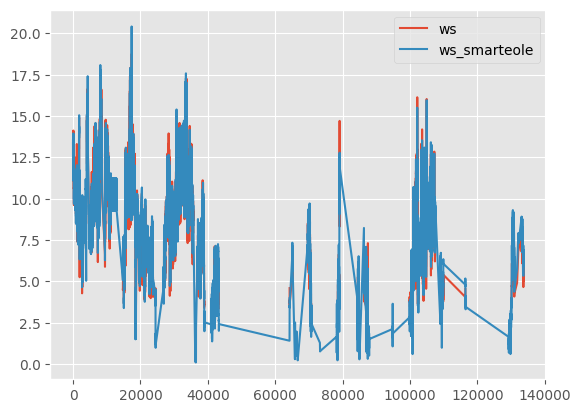

In [47]:
# Use the reference turbine estimated wind speed as wind speed
df_scada = df_scada.assign(
    ws=lambda df_: df_[[f"ws_est_{ti:03d}" for ti in ref_turbs]].mean(axis=1),
)
df_scada[['ws','ws_smarteole']].plot()

In [48]:
# Remove all the power channels except for the test turb to force the
# tuning to focus on that turbine
pow_cols = [c for c in df_scada.columns if c.startswith("pow_") and c != f"pow_{test_turbs[0]}"]
df_scada = df_scada.drop(columns=pow_cols)

## Split the data into day and night

In [49]:
# Split SCADA into baseline and wake steeering (controlled)
df_scada_baseline = df_scada[df_scada.control_mode == "baseline"]
df_scada_controlled = df_scada[df_scada.control_mode == "controlled"]

In [50]:
# Further split SCADA into day and night
df_scada_baseline_day = df_scada_baseline[df_scada_baseline.is_day]
df_scada_baseline_night = df_scada_baseline[~df_scada_baseline.is_day]
df_scada_controlled_day = df_scada_controlled[df_scada_controlled.is_day]
df_scada_controlled_night = df_scada_controlled[~df_scada_controlled.is_day]

## Tuning recovery

The first element of the wake expansion parameter array is named we_1 in this analysis.  It governs the wake expansion in the empirical gaussian model up to the first defined breakpoint (often 10D).  Given the close spacing it is only necessary to tune this parameter.

In [51]:
# Just tune the first wake expansion parameter
parameter_list = [
    (
        "wake",
        "wake_velocity_parameters",
        "empirical_gauss",
        "wake_expansion_rates",
    )
]

parameter_name_list = [
    "we_1",
]

parameter_range_list = [
    (0.0, 0.2),
]

parameter_index_list = [0]

# Baseline tuning

Tune we_1 to the best fit for all the baseline data

In [52]:
# Model Fit object
mf = ModelFit(
    df_scada_baseline,
    fm,
    turbine_power_error_abs,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
)

In [53]:
# Compute the default cost
print("Evaluating cost with default parameters")
default_cost = mf.evaluate_floris()
print(f"Default cost: {default_cost}")

Evaluating cost with default parameters
Default cost: nan


In [54]:
# Optimization
n_trials = 30
opt_result, study = atomic_opt_optuna(mf, timeout=None, n_trials=n_trials)

[I 2025-08-01 14:30:57,237] A new study created in memory with name: ModelFit
[W 2025-08-01 14:31:01,654] Trial 0 failed with parameters: {'we_1': 0.01} because of the following error: The value nan is not acceptable.
[W 2025-08-01 14:31:01,655] Trial 0 failed with value nan.
[W 2025-08-01 14:31:06,061] Trial 1 failed with parameters: {'we_1': 0.10976270078546496} because of the following error: The value nan is not acceptable.
[W 2025-08-01 14:31:06,062] Trial 1 failed with value nan.
[W 2025-08-01 14:31:10,392] Trial 2 failed with parameters: {'we_1': 0.1430378732744839} because of the following error: The value nan is not acceptable.
[W 2025-08-01 14:31:10,392] Trial 2 failed with value nan.
[W 2025-08-01 14:31:14,823] Trial 3 failed with parameters: {'we_1': 0.12055267521432877} because of the following error: The value nan is not acceptable.
[W 2025-08-01 14:31:14,823] Trial 3 failed with value nan.
[W 2025-08-01 14:31:19,193] Trial 4 failed with parameters: {'we_1': 0.10897663659

ValueError: No trials are completed yet.

In [15]:
# Print the best result
we_1_baseline = opt_result["parameter_values"][0]

print(f"Best we_1 from baseline tuning: {we_1_baseline}")


Best we_1 from baseline tuning: 0.028594465574653612


### Show some optimization plots

/var/folders/zl/d69s6z796rs4fw08fnxrl0qxydms74/T/ipykernel_44570/1159364915.py:2: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  plot_slice(study)


<Axes: title={'center': 'Slice Plot'}, xlabel='we_1', ylabel='Objective Value'>

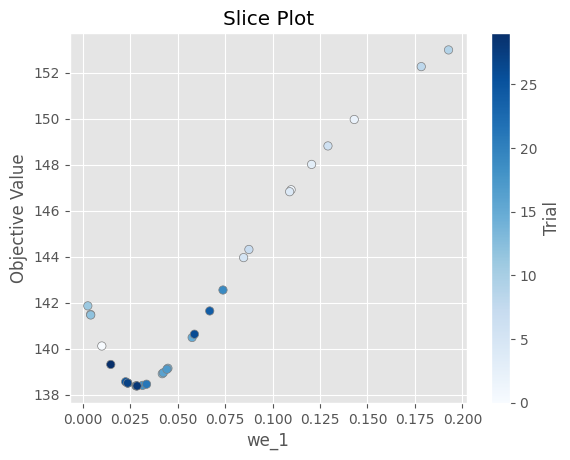

In [16]:
# Since this is a single parameter optimization, the slice plot is the most informative
plot_slice(study)

# Tune the recovery to baseline day and night data

Using the data split into

#### Daytime result

In [ ]:
mf_day = ModelFit(
    df_scada_baseline_day,
    fm,
    turbine_power_error_abs,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
)

opt_result_day, study_day = atomic_opt_optuna(mf_day, timeout=None, n_trials=n_trials)

we_1_baseline_day = opt_result_day["parameter_values"][0]

print(f"Best we_1 for day: {we_1_baseline_day}")


[I 2025-08-01 14:00:03,464] A new study created in memory with name: ModelFit
[I 2025-08-01 14:00:05,890] Trial 0 finished with value: 149.06980961703889 and parameters: {'we_1': 0.01471696447711797}. Best is trial 0 with value: 149.06980961703889.
[I 2025-08-01 14:00:07,635] Trial 1 finished with value: 152.51722863902097 and parameters: {'we_1': 0.10976270078546496}. Best is trial 0 with value: 149.06980961703889.
[I 2025-08-01 14:00:09,402] Trial 2 finished with value: 155.26129119713045 and parameters: {'we_1': 0.1430378732744839}. Best is trial 0 with value: 149.06980961703889.
[I 2025-08-01 14:00:11,131] Trial 3 finished with value: 153.48903095220325 and parameters: {'we_1': 0.12055267521432877}. Best is trial 0 with value: 149.06980961703889.
[I 2025-08-01 14:00:12,892] Trial 4 finished with value: 152.4435175080889 and parameters: {'we_1': 0.10897663659937938}. Best is trial 0 with value: 149.06980961703889.
[I 2025-08-01 14:00:14,865] Trial 5 finished with value: 150.02566914

Best we_1 for day: 0.03642614499113272


#### Night reults

In [ ]:
mf_night = ModelFit(
    df_scada_baseline_night,
    fm,
    turbine_power_error_abs,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
)

opt_result_night, study_night = atomic_opt_optuna(mf_night, timeout=None, n_trials=n_trials)

we_1_baseline_night = opt_result_night["parameter_values"][0]

print(f"Best we_1 for night: {we_1_baseline_night}")

[I 2025-08-01 14:00:57,609] A new study created in memory with name: ModelFit
[I 2025-08-01 14:00:59,426] Trial 0 finished with value: 129.72904722652808 and parameters: {'we_1': 0.018791447022705857}. Best is trial 0 with value: 129.72904722652808.
[I 2025-08-01 14:01:01,052] Trial 1 finished with value: 141.55054815424782 and parameters: {'we_1': 0.10976270078546496}. Best is trial 0 with value: 129.72904722652808.
[I 2025-08-01 14:01:02,615] Trial 2 finished with value: 144.91160024162096 and parameters: {'we_1': 0.1430378732744839}. Best is trial 0 with value: 129.72904722652808.
[I 2025-08-01 14:01:04,181] Trial 3 finished with value: 142.7808756632372 and parameters: {'we_1': 0.12055267521432877}. Best is trial 0 with value: 129.72904722652808.
[I 2025-08-01 14:01:05,748] Trial 4 finished with value: 141.45522023178358 and parameters: {'we_1': 0.10897663659937938}. Best is trial 0 with value: 129.72904722652808.
[I 2025-08-01 14:01:07,397] Trial 5 finished with value: 138.1511985

Best we_1 for night: 0.020652243430126796


### Plot comparison

#### DAY

/var/folders/zl/d69s6z796rs4fw08fnxrl0qxydms74/T/ipykernel_44570/2025952639.py:1: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  plot_slice(study_day)


<Axes: title={'center': 'Slice Plot'}, xlabel='we_1', ylabel='Objective Value'>

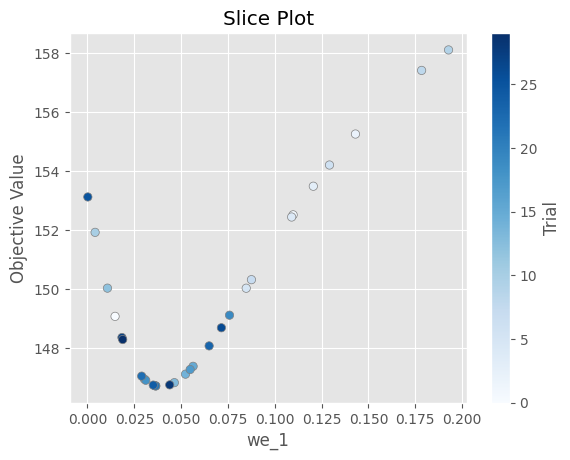

In [19]:
plot_slice(study_day)

#### NIGHT

/var/folders/zl/d69s6z796rs4fw08fnxrl0qxydms74/T/ipykernel_44570/2177333560.py:1: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  plot_slice(study_night)


<Axes: title={'center': 'Slice Plot'}, xlabel='we_1', ylabel='Objective Value'>

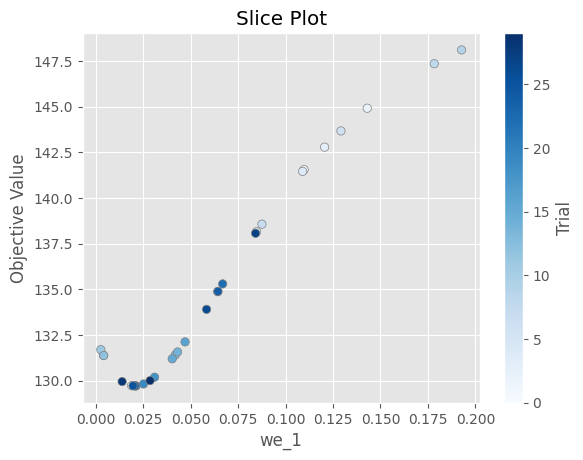

In [20]:
plot_slice(study_night)

# Update the FLORIS model with the best parameters

In [21]:
fm_baseline = fm.copy()
fm_baseline_day = fm.copy()
fm_baseline_night = fm.copy()

fm_baseline.set_param(parameter_list[0], we_1_baseline, 0)
fm_baseline_day.set_param(parameter_list[0], we_1_baseline_day, 0)
fm_baseline_night.set_param(parameter_list[0], we_1_baseline_night, 0)

## Tune the deflection parameter

Tune horizontal deflection gain, first to all data, then to day and night data

In [22]:
# Just tune the first wake expansion parameter
parameter_list = [
    (
        "wake",
        "wake_deflection_parameters",
        "empirical_gauss",
        "horizontal_deflection_gain_D",
    )
]

parameter_name_list = [
    "deflection_gain",
]

parameter_range_list = [
    (0.0, 5.0),
]

parameter_index_list = [None]

In [23]:
# Set the yaw angle matrix
yaw_vec = df_scada_controlled.wind_vane_005

yaw_angles = np.zeros((yaw_vec.shape[0], 7))
yaw_angles[:, control_turbs[0]] = yaw_vec

In [26]:
mf = ModelFit(
    df_scada_controlled,
    fm_baseline,  # Use the model tuned to all baseline data
    turbine_power_error_abs,
    parameter_list=parameter_list,
    parameter_name_list=parameter_name_list,
    parameter_range_list=parameter_range_list,
    parameter_index_list=parameter_index_list,
    yaw_angles=yaw_angles,
)

In [27]:
# Compute the default cost
print("Evaluating cost with default parameters")
default_cost = mf.evaluate_floris()
print(f"Default cost: {default_cost}")

Evaluating cost with default parameters
Default cost: 148.66853787329


In [28]:
# Optimization
n_trials = 20
opt_result, study = atomic_opt_optuna(mf, timeout=None, n_trials=n_trials)

def_gain = opt_result["parameter_values"][0]
print(f"Best deflection gain: {def_gain}")

[I 2025-08-01 14:11:08,367] A new study created in memory with name: ModelFit
[I 2025-08-01 14:11:15,705] Trial 0 finished with value: 148.66853787329 and parameters: {'deflection_gain': 3.0}. Best is trial 0 with value: 148.66853787329.
[I 2025-08-01 14:11:23,328] Trial 1 finished with value: 148.62196488356318 and parameters: {'deflection_gain': 2.7440675196366238}. Best is trial 1 with value: 148.62196488356318.
[I 2025-08-01 14:11:30,625] Trial 2 finished with value: 148.79980406806766 and parameters: {'deflection_gain': 3.5759468318620975}. Best is trial 1 with value: 148.62196488356318.
[I 2025-08-01 14:11:38,158] Trial 3 finished with value: 148.6712712400244 and parameters: {'deflection_gain': 3.0138168803582195}. Best is trial 1 with value: 148.62196488356318.
[I 2025-08-01 14:11:45,597] Trial 4 finished with value: 148.61871409000236 and parameters: {'deflection_gain': 2.724415914984484}. Best is trial 4 with value: 148.61871409000236.
[I 2025-08-01 14:11:52,817] Trial 5 fini

/var/folders/zl/d69s6z796rs4fw08fnxrl0qxydms74/T/ipykernel_44570/2457830863.py:1: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  plot_slice(study)


<Axes: title={'center': 'Slice Plot'}, xlabel='deflection_gain', ylabel='Objective Value'>

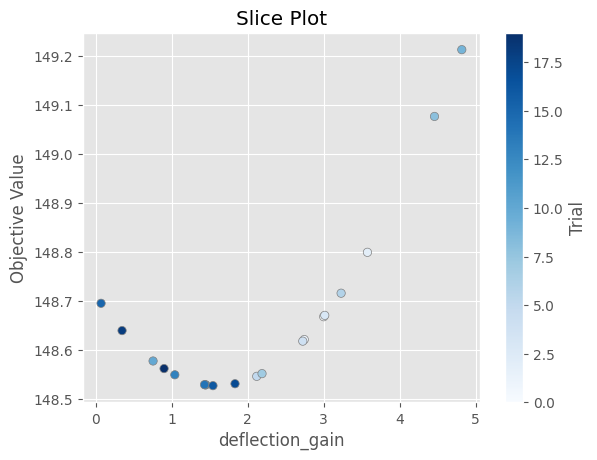

In [ ]:
plot_slice(study)